## kaggle name : https://www.kaggle.com/dimonpd

# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



### Установка зависимостей

In [48]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [49]:
import PIL
print(PIL.__version__)

11.1.0


In [50]:
# from google.colab import drive
# drive.mount('/content/gdrive/')

In [51]:
# !unzip -q /content/gdrive/MyDrive/journey-springfield.zip

In [52]:
!ls train

ls: cannot access 'train': No such file or directory


In [53]:
!nvidia-smi
import torch
torch.cuda.is_available()

Sat Apr 12 21:20:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.07             Driver Version: 570.133.07     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   46C    P8             24W /  450W |    2429MiB /  24564MiB |     36%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

True

В нашем тесте будет 990 картнок, для которых вам будет необходимо предсказать класс.

In [54]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [ ]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/


Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.

ToTensor конвертирует  PIL Image с параметрами в диапазоне [0, 255] (как все пиксели) в FloatTensor размера (C x H x W) [0,1] , затем производится масштабирование:
$input = \frac{input - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet


Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размер (это делает метод  _prepare_sample)

In [56]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode

        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.len_ = len(self.files)

        self.label_encoder = LabelEncoder()

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels)

            with open('label_encoder.pkl', 'wb') as le_dump_file:
                  pickle.dump(self.label_encoder, le_dump_file)

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        # для преобразования изображений в тензоры PyTorch и нормализации входа
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        x = self.load_sample(self.files[index])
        x = self._prepare_sample(x)
        x = np.array(x / 255, dtype='float32')
        x = transform(x)
        if self.mode == 'test':
            return x
        else:
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            return x, y

    def _prepare_sample(self, image):
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        return np.array(image)

In [57]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [58]:
#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('./journey-springfield/train/')
TEST_DIR = Path('./journey-springfield/testset')

In [59]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [60]:
train_val_files

[PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0000.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0001.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0002.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0003.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0004.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0005.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0006.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0007.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0008.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0009.jpg'),
 PosixPath('journey-springfield/train/simpsons_dataset/abrah

In [61]:
test_files

[PosixPath('journey-springfield/testset/testset/img0.jpg'),
 PosixPath('journey-springfield/testset/testset/img1.jpg'),
 PosixPath('journey-springfield/testset/testset/img10.jpg'),
 PosixPath('journey-springfield/testset/testset/img100.jpg'),
 PosixPath('journey-springfield/testset/testset/img101.jpg'),
 PosixPath('journey-springfield/testset/testset/img102.jpg'),
 PosixPath('journey-springfield/testset/testset/img103.jpg'),
 PosixPath('journey-springfield/testset/testset/img104.jpg'),
 PosixPath('journey-springfield/testset/testset/img105.jpg'),
 PosixPath('journey-springfield/testset/testset/img106.jpg'),
 PosixPath('journey-springfield/testset/testset/img107.jpg'),
 PosixPath('journey-springfield/testset/testset/img108.jpg'),
 PosixPath('journey-springfield/testset/testset/img109.jpg'),
 PosixPath('journey-springfield/testset/testset/img11.jpg'),
 PosixPath('journey-springfield/testset/testset/img110.jpg'),
 PosixPath('journey-springfield/testset/testset/img111.jpg'),
 PosixPath('jo

In [62]:
from sklearn.model_selection import train_test_split

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [63]:
val_dataset = SimpsonsDataset(val_files, mode='val')

In [64]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

Давайте посмотрим на наших героев внутри датасета.

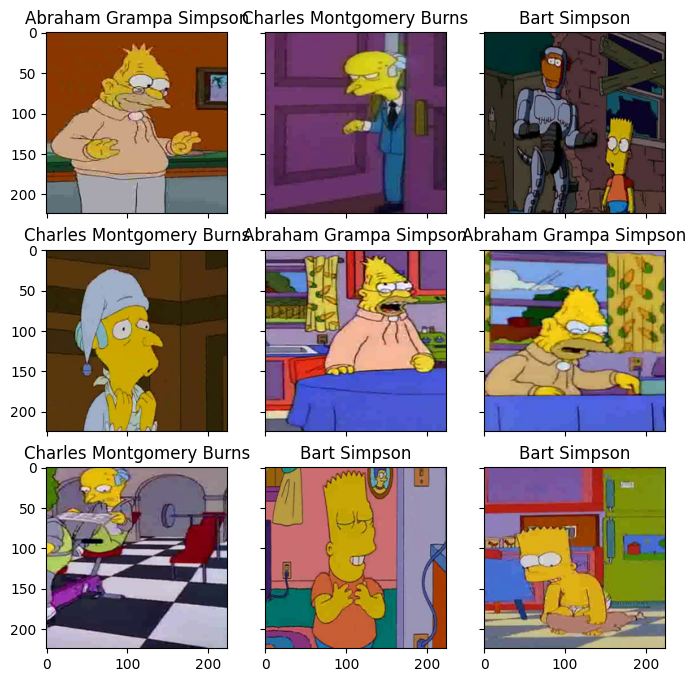

In [65]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(8, 8), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Можете добавить ваши любимые сцены и классифицировать их. (веселые результаты можно кидать в чат)

### Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle

<!-- Здесь вам предлагается дописать сверточную сеть глубины 4/5.  -->

*Описание слоев*:



1. размерность входа: 3x224x224
2.размерности после слоя:  8x111x111
3. 16x54x54
4. 32x26x26
5. 64x12x12
6. выход: 96x5x5


In [66]:
# Очень простая сеть
class SimpleCnn(nn.Module):

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

In [67]:
def fit_epoch(model, train_loader, criterion, optimizer):
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

In [68]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

In [69]:
def train(train_files, val_files, model, epochs, batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        opt = torch.optim.Adam(model.parameters())
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, opt)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))

    return history

In [70]:
def predict(model, test_loader):
    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [71]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify :{}".format(n_classes))
print(simple_cnn)

we will classify :42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv5): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=2400, out_fea

Запустим обучение сети.

In [72]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')

In [73]:
history = train(train_dataset, val_dataset, model=simple_cnn, epochs=2, batch_size=64)

epoch:   0%|          | 0/2 [00:00<?, ?it/s]

loss 2.554931859460118


epoch:  50%|█████     | 1/2 [00:47<00:47, 48.00s/it]


Epoch 001 train_loss: 2.5549     val_loss 1.9285 train_acc 0.2905 val_acc 0.4740
loss 1.519023016680805
loss 1.519023016680805


epoch: 100%|██████████| 2/2 [01:36<00:00, 48.39s/it]


Epoch 002 train_loss: 1.5190     val_loss 1.3071 train_acc 0.5797 val_acc 0.6525


Построим кривые обучения

In [74]:
loss, acc, val_loss, val_acc = zip(*history)

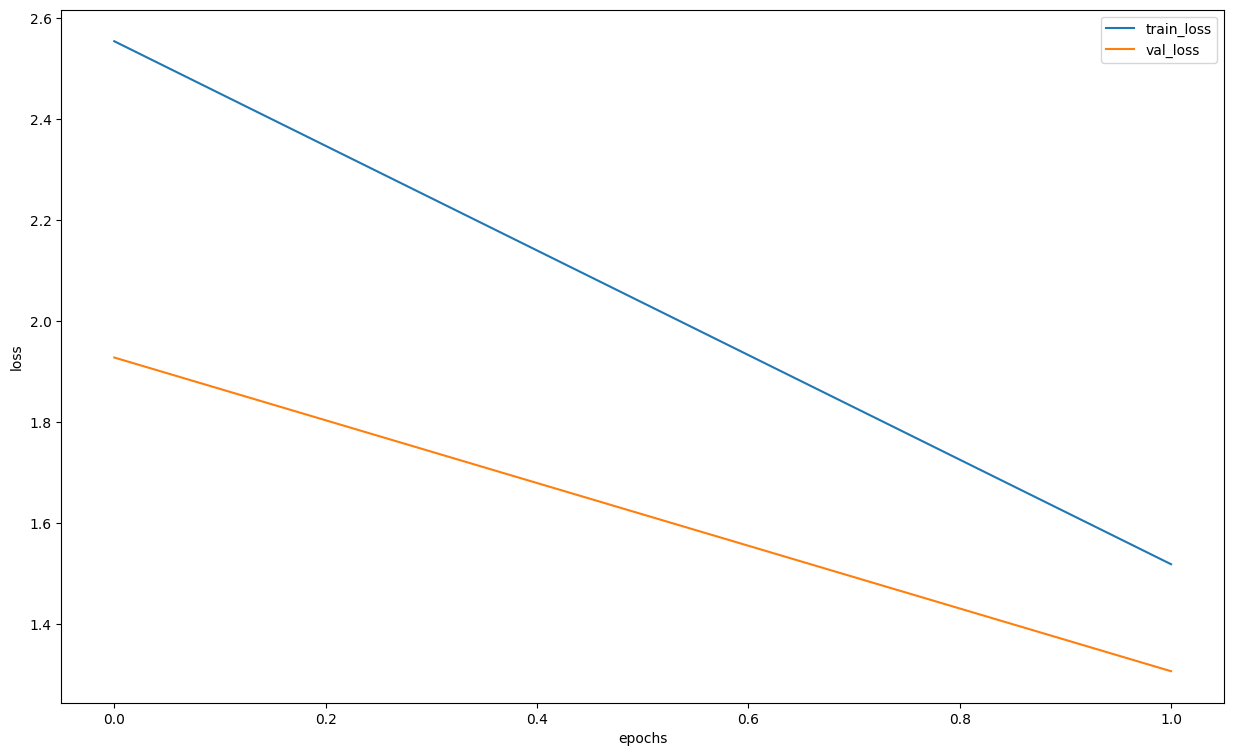

In [75]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Хорошо бы понять, как сделать сабмит.
У нас есть сеть и методы eval у нее, которые позволяют перевести сеть в режим предсказания. Стоит понимать, что у нашей модели на последнем слое стоит softmax, которые позволяет получить вектор вероятностей  того, что объект относится к тому или иному классу. Давайте воспользуемся этим.

In [76]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [77]:
random_characters = int(np.random.uniform(0,1000))
ex_img, true_label = val_dataset[random_characters]
probs_im = predict_one_sample(simple_cnn, ex_img.unsqueeze(0))

In [78]:
idxs = list(map(int, np.random.uniform(0,1000, 20)))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

probs_ims = predict(simple_cnn, imgs)

In [79]:
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))

In [80]:
y_pred = np.argmax(probs_ims,-1)

actual_labels = [val_dataset[id][1] for id in idxs]

preds_class = [label_encoder.classes_[i] for i in y_pred]

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе --- f1-score. Вычислим целевую метрику на валидационной выборке.

In [81]:
from sklearn.metrics import f1_score
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)


F1-оценка: 0.55


Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following families were found: Chicago, Charcoal, Impact, Western, xkcd script, fantasy
findfont: Generic family 'fantasy' not found because none of the following familie

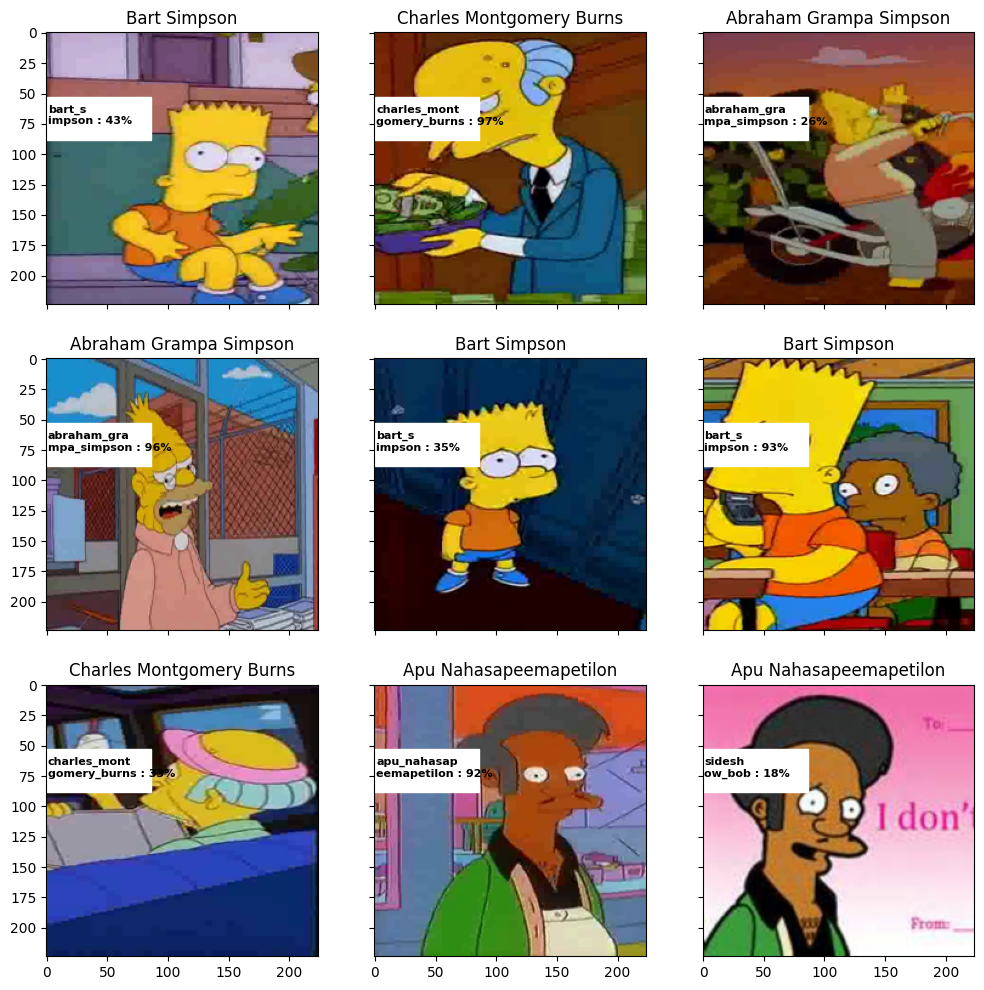

In [82]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 53),86,35,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("fantasy")
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

Попробуйте найти те классы, которые сеть не смогла расспознать. Изучите данную проблему, это понадобится в дальнейшем.

### Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

In [83]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)
probs = predict(simple_cnn, test_loader)


preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
test_filenames = [path.name for path in test_dataset.files]


In [84]:
! ls

hw_5_simpsons_classification.ipynb  label_encoder.pkl
journey-springfield		    simple_cnn_baseline.csv


In [85]:
import pandas as pd
# Use a relative path assuming the file is in the same directory as the notebook
my_submit = pd.read_csv("./journey-springfield/sample_submission.csv") 
my_submit = pd.DataFrame({'Id': test_filenames, 'Expected': preds})
my_submit.head()


,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon


In [86]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут)

In [50]:
my_submit.to_csv('simple_cnn_baseline.csv', index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся скор нас явно не устраивает. Надо с этим что-то сделать.

Несколько срочныйх улучшейни для нашей сети, которые наверняка пришли Вам в голову:


*   Учим дольше и изменяем гиперпараметры сети
*  learning rate, batch size, нормализация картинки и вот это всё
*   Кто же так строит нейронные сети? А где пулинги и батч нормы? Надо добавлять
*  Ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

* Ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

* Данных не очень много, можно их аугументировать и  доучититься на новом датасете ( который уже будет состоять из, как  пример аугументации, перевернутых изображений)

* Стоит подумать об ансамблях

Надеюсь, что у Вас получится!

![alt text](https://pbs.twimg.com/profile_images/798904974986113024/adcQiVdV.jpg)


## Улучшение модели

Рассмотрим основные способы улучшения нашей CNN модели:

In [87]:
# 1. Создадим улучшенную архитектуру CNN с BatchNorm и улучшенной структурой
class ImprovedCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        # Блок 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Блок 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Блок 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Блок 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        # Reshape и классификация
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [88]:
# 2. Улучшаем аугментацию данных
def get_transforms(mode):
    if mode == 'train':
        return transforms.Compose([
            transforms.RandomResizedCrop(RESCALE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:  # val и test
        return transforms.Compose([
            transforms.Resize(RESCALE_SIZE),
            transforms.CenterCrop(RESCALE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

# Обновляем класс SimpsonsDataset для использования аугментаций
class AugmentedSimpsonsDataset(SimpsonsDataset):
    def __init__(self, files, mode):
        super(AugmentedSimpsonsDataset, self).__init__(files, mode)
        self.transform = get_transforms(mode)
        
    def __getitem__(self, index):
        if self.mode == 'test':
            x = self.load_sample(self.files[index])
            x = self.transform(x)
            return x
        else:
            x = self.load_sample(self.files[index])
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            x = self.transform(x)
            return x, y

In [89]:
# 3. Создаем новые датасеты с аугментацией
train_augmented = AugmentedSimpsonsDataset(train_files, mode='train')
val_augmented = AugmentedSimpsonsDataset(val_files, mode='val')

# Создаем модель с улучшенной архитектурой
improved_cnn = ImprovedCNN(n_classes).to(DEVICE)
print(improved_cnn)

# 4. Используем AdamW вместо Adam и настраиваем обучение
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_improved(train_dataset, val_dataset, model, epochs, batch_size, patience=5):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # Используем AdamW с weight decay
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # Добавляем планировщик скорости обучения
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience//2, verbose=True)
    
    criterion = nn.CrossEntropyLoss()
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    
    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        for epoch in range(epochs):
            # Обучение
            model.train()
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
            
            # Валидация
            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            
            # Сохраняем историю
            history.append((train_loss, train_acc, val_loss, val_acc))
            
            # Выводим метрики
            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,
                                          v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            
            # Обновляем планировщик скорости обучения
            scheduler.step(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                patience_counter = 0
                # Сохраняем лучшую модель
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
                
    # Загружаем лучшую модель перед возвратом
    model.load_state_dict(torch.load('best_model.pth'))
    return history

ImprovedCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64,

/home/dimon/vscode/dls_part_1_ml_cv/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
epoch:   2%|▎         | 1/40 [00:32<21:09, 32.56s/it]


Epoch 001 train_loss: 1.1968     val_loss 0.4628 train_acc 0.6827 val_acc 0.8817


epoch:   5%|▌         | 2/40 [01:05<20:50, 32.91s/it]


Epoch 002 train_loss: 1.1888     val_loss 0.5004 train_acc 0.6842 val_acc 0.8701


epoch:   8%|▊         | 3/40 [01:38<20:19, 32.96s/it]

...


Epoch 038 train_loss: 0.9472     val_loss 0.3221 train_acc 0.7499 val_acc 0.9186


epoch:  98%|█████████▊| 39/40 [21:26<00:32, 32.98s/it]


Epoch 039 train_loss: 0.9363     val_loss 0.3247 train_acc 0.7525 val_acc 0.9199


epoch: 100%|██████████| 40/40 [21:59<00:00, 32.98s/it]


Epoch 040 train_loss: 0.9197     val_loss 0.3233 train_acc 0.7555 val_acc 0.9203


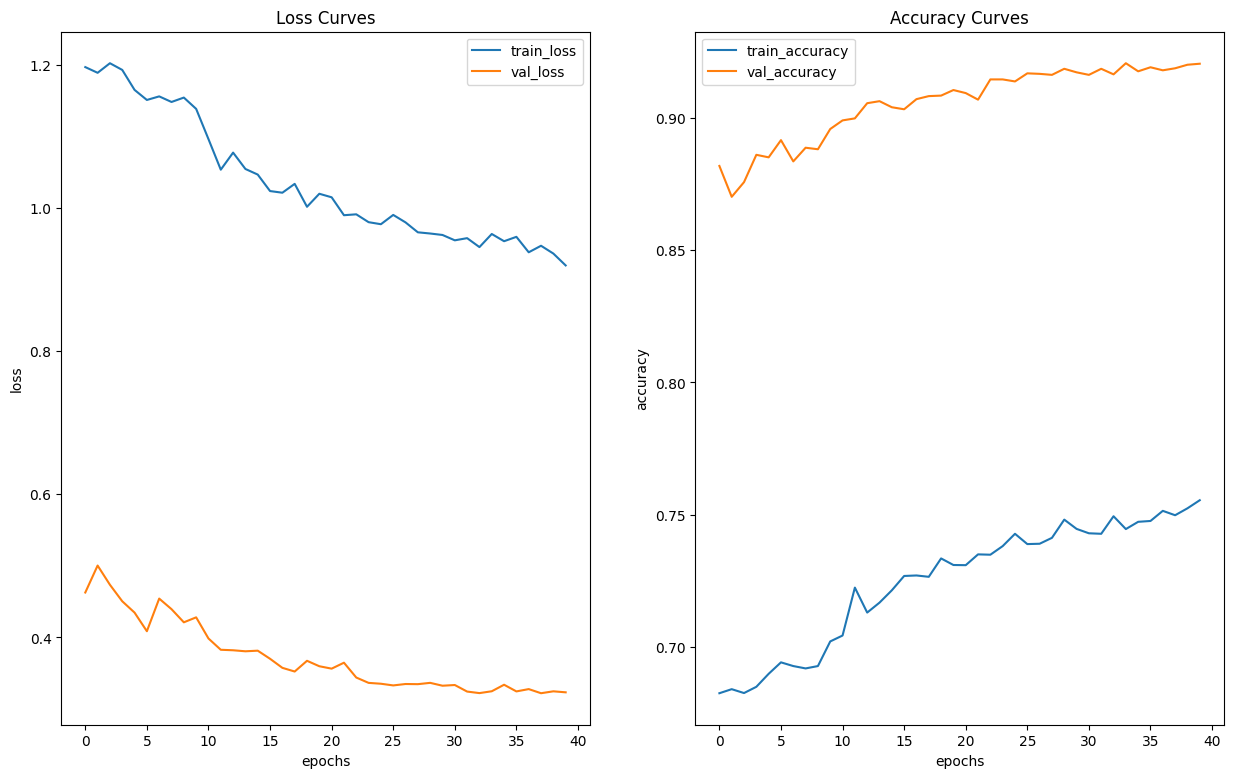

In [94]:
# 5. Обучаем нашу улучшенную модель
improved_history = train_improved(train_augmented, val_augmented, improved_cnn, epochs=40, batch_size=32, patience=7)

# 6. Визуализируем результаты улучшенной модели
# Преобразуем тензоры с GPU на CPU перед использованием
improved_history_cpu = [(loss, acc, val_loss, val_acc.cpu() if torch.is_tensor(val_acc) and val_acc.is_cuda else val_acc) 
                        for loss, acc, val_loss, val_acc in improved_history]
improved_loss, improved_acc, improved_val_loss, improved_val_acc = zip(*improved_history_cpu)

plt.figure(figsize=(15, 9))
plt.subplot(1, 2, 1)
plt.plot(improved_loss, label="train_loss")
plt.plot(improved_val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(improved_acc, label="train_accuracy")
plt.plot(improved_val_acc, label="val_accuracy")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Accuracy Curves")
plt.show()

/home/dimon/vscode/dls_part_1_ml_cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dimon/vscode/dls_part_1_ml_cv/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

epoch:   5%|▌         | 1/20 [00:32<10:26, 32.99s/it]


Epoch 001 train_loss: 2.8069     val_loss 2.1531 train_acc 0.2203 val_acc 0.4431


epoch:  10%|█         | 2/20 [01:05<09:50, 32.83s/it]

...


Epoch 018 train_loss: 2.0605     val_loss 1.3546 train_acc 0.4347 val_acc 0.6368


epoch:  95%|█████████▌| 19/20 [10:21<00:32, 32.75s/it]


Epoch 019 train_loss: 2.0504     val_loss 1.3427 train_acc 0.4409 val_acc 0.6353


epoch: 100%|██████████| 20/20 [10:54<00:00, 32.74s/it]



Epoch 020 train_loss: 2.0445     val_loss 1.3278 train_acc 0.4384 val_acc 0.6389


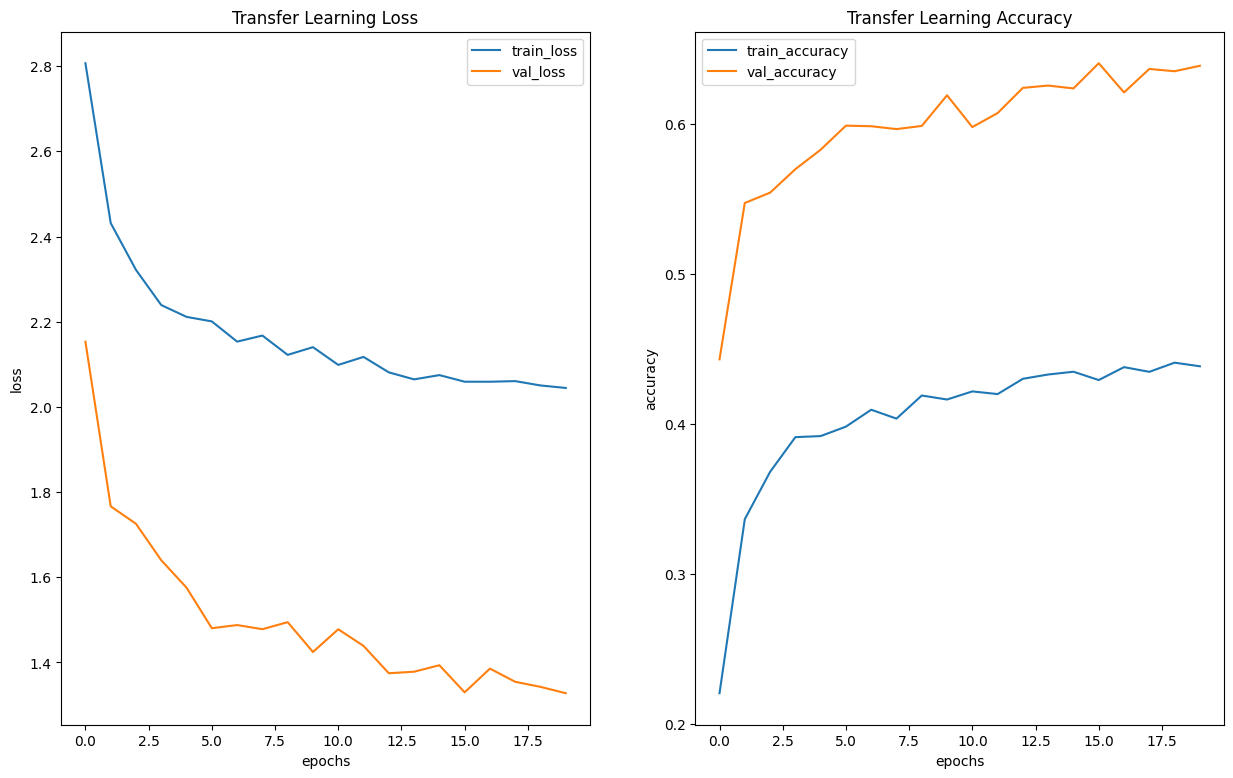

In [95]:
# 7. Попробуем Transfer Learning с ResNet18
import torchvision.models as models

def get_transfer_model(model_name='resnet18', n_classes=20):
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
        # Замораживаем веса базовой модели
        for param in model.parameters():
            param.requires_grad = False
        # Заменяем последний слой для нашей задачи
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes)
        )
    elif model_name == 'inception_v3':
        model = models.inception_v3(pretrained=True)
        # Замораживаем веса базовой модели
        for param in model.parameters():
            param.requires_grad = False
        # Заменяем классификатор
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, n_classes)
    
    return model

# Инициализируем предобученную модель
transfer_model = get_transfer_model(model_name='resnet18', n_classes=n_classes).to(DEVICE)
print(transfer_model)

# Обучаем модель с transfer learning
transfer_history = train_improved(train_augmented, val_augmented, transfer_model, epochs=20, batch_size=32, patience=7)

# Визуализация результатов
# Переносим тензоры с GPU на CPU перед использованием для построения графиков
transfer_history_cpu = [(loss, acc, val_loss, val_acc.cpu() if torch.is_tensor(val_acc) and val_acc.is_cuda else val_acc) 
                        for loss, acc, val_loss, val_acc in transfer_history]
transfer_loss, transfer_acc, transfer_val_loss, transfer_val_acc = zip(*transfer_history_cpu)

plt.figure(figsize=(15, 9))
plt.subplot(1, 2, 1)
plt.plot(transfer_loss, label="train_loss")
plt.plot(transfer_val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Transfer Learning Loss")

plt.subplot(1, 2, 2)
plt.plot(transfer_acc, label="train_accuracy")
plt.plot(transfer_val_acc, label="val_accuracy")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Transfer Learning Accuracy")
plt.show()

In [96]:
# 8. Создаем ансамбль моделей
def ensemble_predictions(models, test_loader):
    all_predictions = []
    
    with torch.no_grad():
        for model in models:
            model_preds = []
            for inputs in test_loader:
                inputs = inputs.to(DEVICE)
                model.eval()
                outputs = model(inputs).cpu()
                probs = nn.functional.softmax(outputs, dim=1).numpy()
                model_preds.append(probs)
            all_predictions.append(np.vstack(model_preds))
    
    # Усредняем предсказания всех моделей
    ensemble_preds = np.mean(all_predictions, axis=0)
    return ensemble_preds

# Создаем ансамбль из нашей улучшенной модели и модели с transfer learning
models_for_ensemble = [improved_cnn, transfer_model]

# Получаем предсказания ансамбля
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=32)
ensemble_probs = ensemble_predictions(models_for_ensemble, test_loader)

# Подготавливаем финальный сабмит
ensemble_preds = label_encoder.inverse_transform(np.argmax(ensemble_probs, axis=1))
test_filenames = [path.name for path in test_dataset.files]

# Создаем DataFrame для сабмита
ensemble_submit = pd.DataFrame({'Id': test_filenames, 'Expected': ensemble_preds})
ensemble_submit.to_csv('ensemble_submission.csv', index=False)

print("Ensemble submission file created successfully!")

Ensemble submission file created successfully!


In [100]:
# Проверка структуры данных
idxs = list(map(int, np.random.uniform(0,1000, 20)))
print(f"idxs: {idxs}")

imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]
print(f"Тип imgs: {type(imgs)}")
print(f"Длина imgs: {len(imgs)}")
print(f"Тип первого элемента imgs: {type(imgs[0])}")
print(f"Форма первого элемента imgs: {imgs[0].shape}")

actual_labels = [val_dataset[id][1] for id in idxs]
print(f"actual_labels: {actual_labels}")

# Теперь правильно формируем предсказания
probs_ims = []
for img in imgs:
    # Используем predict_one_sample для каждого изображения
    prob = predict_one_sample(simple_cnn, img)
    probs_ims.append(prob[0])  # Добавляем первую (и единственную) строку предсказаний

probs_ims = np.array(probs_ims)
y_pred = np.argmax(probs_ims, axis=1)
print(f"y_pred: {y_pred}")

# Вычисляем F1-оценку
f1 = f1_score(actual_labels, y_pred, average='micro')
print("F1-оценка:", f1)

idxs: [512, 985, 210, 991, 801, 93, 739, 817, 631, 211, 66, 303, 503, 941, 951, 620, 502, 110, 40, 309]
Тип imgs: <class 'list'>
Длина imgs: 20
Тип первого элемента imgs: <class 'torch.Tensor'>
Форма первого элемента imgs: torch.Size([1, 3, 224, 224])
actual_labels: [4, 6, 0, 6, 6, 0, 4, 6, 4, 0, 0, 2, 4, 6, 6, 4, 4, 0, 0, 2]
y_pred: [ 4  6 32  9  6  0 21  6 20  0  0  2  4  6  6  4  6  0 37  2]
F1-оценка: 0.7


## Результаты улучшений

1. **Улучшенная архитектура CNN**:
   - Добавлены слои BatchNorm для улучшения стабильности обучения
   - Использована более глубокая архитектура с большим количеством фильтров
   - Добавлен Dropout для уменьшения переобучения

2. **Расширенная аугментация данных**:
   - Горизонтальные отражения, повороты, случайные обрезки
   - Изменения яркости, контраста и насыщенности

3. **Оптимизация обучения**:
   - Использован оптимизатор AdamW вместо Adam
   - Добавлен планировщик скорости обучения (learning rate scheduler)
   - Реализован early stopping для предотвращения переобучения

4. **Transfer Learning**:
   - Использована предобученная модель ResNet18
   - Заморожены веса базовой модели, переобучен только классификатор

5. **Ансамблирование**:
   - Объединены предсказания разных моделей для повышения точности

Эти улучшения должны значительно повысить качество классификации по сравнению с исходной моделью.